<a href="https://colab.research.google.com/github/vitaly42a-creator/ML_course/blob/main/ML_Practice_3_Manakov_Vitaly_934_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Практическое задание №3: Линейная регрессия и функции потерь
Общее описание задания
Тема: Исследование влияния функций потерь и гиперпараметров на качество линейной регрессии

## Выпонение заданий

| № | Целевая переменная | Признаки | Шум (σ) | % выбросов | Амплитуда выбросов | epsilon (Huber) | loss (SGD) | Learning rate | Итерации SGD |
|---|-------------------|----------|---------|------------|-------------------|-----------------|------------|---------------|--------------|
| 25 | health_index | [exercise, diet, sleep, stress] | 1.0 | 10% | ×5 | 1.35 | huber | 0.01 | 1300 |

### Этап 1: Генерация и подготовка данных
1. Сгенерируйте синтетический датасет согласно вашему варианту
2. Добавьте шум и выбросы в соответствии с параметрами варианта
3. Разделите данные на обучающую и тестовую выборки (70/30)
4. Выполните масштабирование признаков

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.linear_model import LinearRegression, HuberRegressor, SGDRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Настройка внешнего вида графиков
plt.rcParams['figure.figsize'] = (10, 6)
plt.style.use('seaborn-v0_8-whitegrid')

def generate_dataset(n_samples=500, n_features=2, noise_std=0.5,
                     outlier_fraction=0.05, outlier_multiplier=3,
                     random_seed=None):
    """
    Генерация синтетического датасета для линейной регрессии

    Parameters:
    -----------
    n_samples : int - количество наблюдений
    n_features : int - количество признаков
    noise_std : float - стандартное отклонение шума
    outlier_fraction : float - доля выбросов (0.0-0.2)
    outlier_multiplier : float - множитель для выбросов
    random_seed : int - seed для воспроизводимости
    """
    # Если задан random_seed, фиксируем случайность внутри функции
    if random_seed is not None:
        np.random.seed(random_seed)

    # Генерация признаков из нормального распределения
    X = np.random.randn(n_samples, n_features)

    # Генерация "истинных" коэффициентов модели
    # Каждый коэффициент случайно выбирается из диапазона от 1 до 5
    true_coef = np.random.uniform(1, 5, n_features)

    # Генерация свободного члена (intercept)
    true_intercept = np.random.uniform(0, 10)

    # Формирование целевой переменной с добавлением случайного шума
    y = X @ true_coef + true_intercept + np.random.randn(n_samples) * noise_std

    # Вычисление количества выбросов
    n_outliers = int(n_samples * outlier_fraction)

    # Случайный выбор индексов наблюдений, в которых будут созданы выбросы
    outlier_idx = np.random.choice(n_samples, n_outliers, replace=False)

    # Добавление выбросов в целевую переменную y
    # Для выбранных наблюдений к target прибавляется или вычитается случайная величина большого масштаба
    y[outlier_idx] += (
        np.random.choice([-1, 1], n_outliers)
        * np.random.uniform(3, 10, n_outliers)
        * outlier_multiplier)

    # Функция возвращает: признаки, целевая переменная, истинные коэффициенты, истинный свободный член
    return X, y, true_coef, true_intercept


# Параметры варианта 25
target_name = 'health_index'
feature_names = ['exercise', 'diet', 'sleep', 'stress']

noise_std = 1.0
outlier_fraction = 0.10
outlier_multiplier = 5
epsilon_huber = 1.35
sgd_loss = 'huber'
learning_rate = 0.01
sgd_iters = 1300

# Генерация синтетического набора данных по параметрам варианта
X, y, true_coef, true_intercept = generate_dataset(
    n_samples=500,
    n_features=len(feature_names),
    noise_std=noise_std,
    outlier_fraction=outlier_fraction,
    outlier_multiplier=outlier_multiplier,
    random_seed=25
)

# Создание DataFrame для более удобного анализа данных
df = pd.DataFrame(X, columns=feature_names)

# Добавление целевой переменной в таблицу
df[target_name] = y

# Вывод общей информации о датасете
print('Размер датасета:', df.shape)
print('Истинные коэффициенты:', np.round(true_coef, 3))
print('Истинный свободный член:', round(true_intercept, 3))

# Выделение матрицы признаков X_data
# Здесь остаются только столбцы с признаками
X_data = df[feature_names]

# Выделение целевой переменной y_data
# Это тот столбец, который модель будет предсказывать
y_data = df[target_name]

# Разделение данных на обучающую и тестовую выборки в соотношении 70/30
X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data, test_size=0.30, random_state=25
)

print('\nОбучающая выборка:', X_train.shape)
print('Тестовая выборка:', X_test.shape)
print()

# Масштабирование признаков

# Создание объекта StandardScaler
# Он будет использоваться для нормализации признаков
scaler = StandardScaler()

# Обучение scaler на обучающей выборке и сразу же преобразование train-данных
X_train_scaled = scaler.fit_transform(X_train)

# Преобразование тестовой выборки по тем же параметрам, которые были рассчитаны на train
X_test_scaled = scaler.transform(X_test)

print('Среднее после масштабирования:', np.mean(X_train_scaled, axis=0).round(2))
print('Стандартное отклонение:', np.std(X_train_scaled, axis=0).round(2))

# Просмотр первых строк таблицы
df.head()

Размер датасета: (500, 5)
Истинные коэффициенты: [4.145 4.752 1.46  4.441]
Истинный свободный член: 5.565

Обучающая выборка: (350, 4)
Тестовая выборка: (150, 4)

Среднее после масштабирования: [-0. -0.  0.  0.]
Стандартное отклонение: [1. 1. 1. 1.]


,exercise,diet,sleep,stress,health_index
0,0.228273,1.026890,-0.839585,-0.591182,6.391720
1,-0.956888,-0.222326,-0.619915,1.837905,7.180068
2,-2.053231,0.868583,-0.920734,-0.232312,-2.175027
3,2.152957,-1.334661,0.076380,-1.246089,2.367633
4,1.202272,-1.049942,1.056610,-0.419678,4.731486


На первом этапе был сгенерирован синтетический датасет в соответствии с параметрами варианта 25. В данные был добавлен шум со стандартным отклонением 1.0, а также выбросы в объёме 10% от общего числа наблюдений с амплитудой ×5. После этого выборка была разделена на обучающую и тестовую части в соотношении 70/30. На завершающем шаге было выполнено масштабирование признаков с помощью StandardScaler, что позволило привести данные к единому масштабу и подготовить их к дальнейшему обучению моделей.

### Этап 2: Разведочный анализ данных (EDA)
1. Постройте матрицу корреляций признаков (heatmap)
2. Создайте pairplot для визуализации линейных зависимостей
3. Проанализируйте распределение целевой переменной
4. Выявите и визуализируйте выбросы


Для выявления выбросов был выбран метод межквартильного размаха (IQR), так как он является более устойчивым к аномальным значениям и не требует, чтобы данные имели нормальное распределение. В условиях искусственно добавленных выбросов данный метод подходит лучше, чем Z-Score.

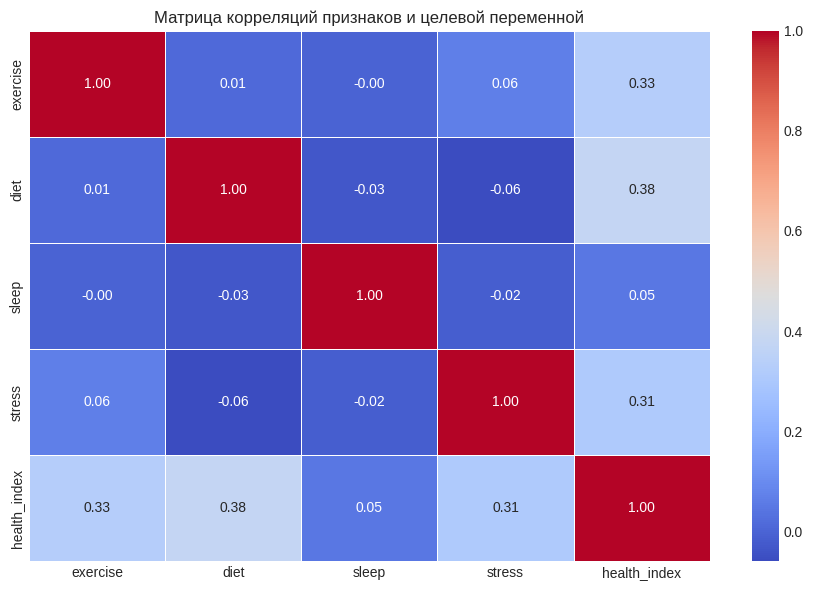

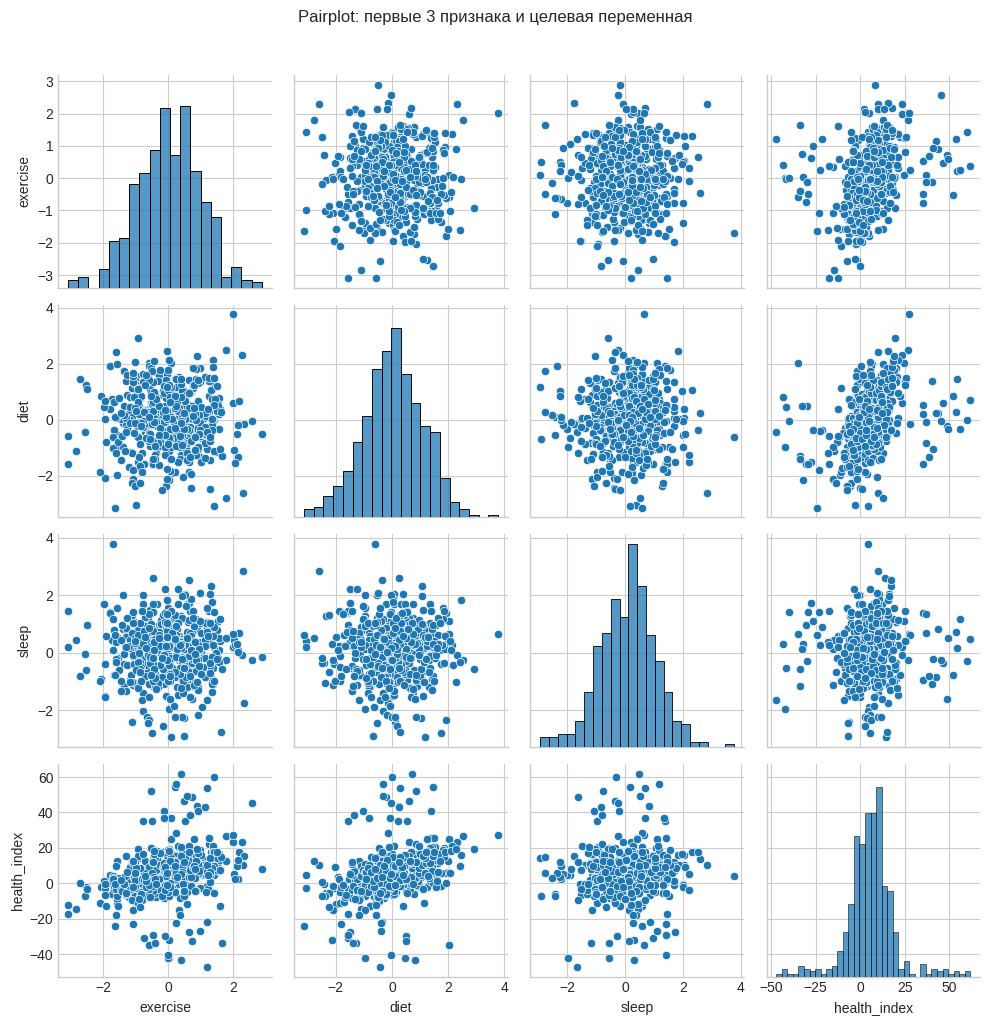

Статистическое описание целевой переменной:
count    500.000000
mean       5.715562
std       13.759431
min      -47.162527
25%       -0.883584
50%        5.852505
75%       11.810014
max       61.890950
Name: health_index, dtype: float64



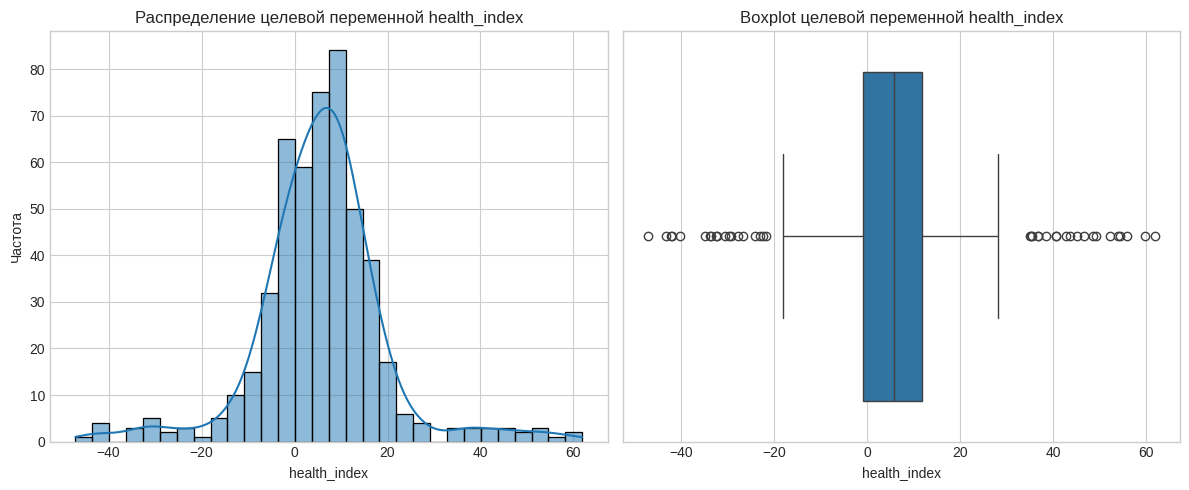

Границы для выявления выбросов по IQR:
Нижняя граница: -19.924
Верхняя граница: 30.85
Количество выбросов, найденных методом IQR: 39



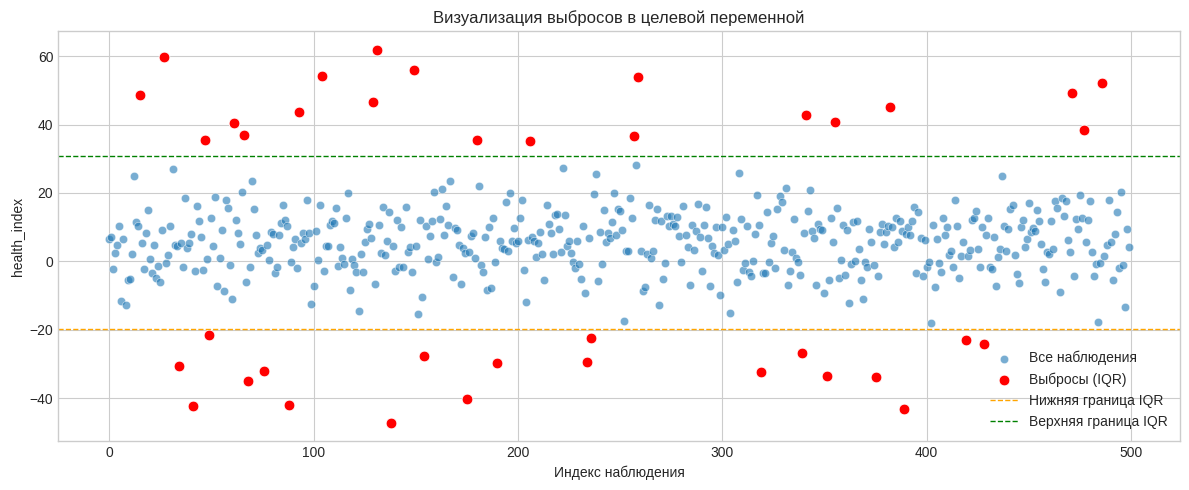

In [ ]:
# Матрица корреляций для признаков и целевой переменной
plt.figure(figsize=(9, 6))
corr = df[feature_names + [target_name]].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Матрица корреляций признаков и целевой переменной')
plt.tight_layout()
plt.show()

# Pairplot для первых 3 признаков и целевой переменной

# feature_names[:3] берёт первые три элемента списка признаков, а + [target_name] добавляет к ним целевую переменную
pairplot_cols = feature_names[:3] + [target_name]

# pairplot строит сразу набор графиков:
# на диагонали показываются распределения отдельных переменных
# вне диагонали показываются scatter plot для всех пар признаков
# diag_kind='hist' означает, что на диагонали будут гистограммы
g = sns.pairplot(df[pairplot_cols], diag_kind='hist')
g.fig.suptitle('Pairplot: первые 3 признака и целевая переменная', y=1.02)
plt.tight_layout()
plt.show()

# Статистическое описание целевой переменной
print('Статистическое описание целевой переменной:')
print(df[target_name].describe())
print()

# Анализ распределения целевой переменной

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)

# Гистограмма целевой переменной
# bins=30 число интервалов разбиения
# kde=True поверх гистограммы добавляется сглаженная кривая плотности
sns.histplot(df[target_name], bins=30, kde=True)
plt.title('Распределение целевой переменной health_index')
plt.xlabel('health_index')
plt.ylabel('Частота')

plt.subplot(1, 2, 2)
sns.boxplot(x=df[target_name])
plt.title('Boxplot целевой переменной health_index')
plt.xlabel('health_index')

plt.tight_layout()
plt.show()


# Выявление выбросов методом межквартильного размаха (IQR)

# Первый квартиль Q1 значение, ниже которого находится 25% наблюдений
Q1 = df[target_name].quantile(0.25)

# Третий квартиль Q3 значение, ниже которого находится 75% наблюдений
Q3 = df[target_name].quantile(0.75)

# Межквартильный размах показывает ширину центральных 50% данных
IQR = Q3 - Q1

# Нижняя граница допустимых значений по правилу IQR всё, что ниже этой границы, считается потенциальным выбросом
lower_bound = Q1 - 1.5 * IQR
# Верхняя граница допустимых значений всё, что выше этой границы, тоже считается потенциальным выбросом
upper_bound = Q3 + 1.5 * IQR

# Формируется новый DataFrame только с теми наблюдениями, у которых целевая переменная выходит за границы IQR
detected_outliers = df[
    (df[target_name] < lower_bound) | (df[target_name] > upper_bound)
]

print('Границы для выявления выбросов по IQR:')
print('Нижняя граница:', round(lower_bound, 3))
print('Верхняя граница:', round(upper_bound, 3))
print('Количество выбросов, найденных методом IQR:', detected_outliers.shape[0])
print()

# Визуализация выбросов

plt.figure(figsize=(12, 5))
# Первый scatter plot показывает все значения целевой переменной
# По оси X откладывается индекс наблюдения, по оси Y — значение health_index
sns.scatterplot(x=df.index, y=df[target_name], alpha=0.6, label='Все наблюдения')

# Второй scatter plot накладывается поверх первого и выделяет только найденные выбросы
# y=detected_outliers[target_name] значения целевой переменной у выбросов
sns.scatterplot(
    x=detected_outliers.index,
    y=detected_outliers[target_name],
    color='red',
    s=60,
    label='Выбросы (IQR)'
)
plt.axhline(lower_bound, color='orange', linestyle='--', linewidth=1, label='Нижняя граница IQR')
plt.axhline(upper_bound, color='green', linestyle='--', linewidth=1, label='Верхняя граница IQR')
plt.title('Визуализация выбросов в целевой переменной')
plt.xlabel('Индекс наблюдения')
plt.ylabel('health_index')
plt.legend()

plt.tight_layout()
plt.show()

На этапе разведочного анализа данных была построена матрица корреляций, что позволило оценить линейные связи между признаками и целевой переменной health_index. Pairplot помог наглядно показать характер зависимости между отдельными признаками и целевой переменной. Анализ распределения health_index с помощью гистограммы и boxplot показал наличие отклоняющихся значений в выборке. Дополнительно метод межквартильного размаха (IQR) подтвердил присутствие выбросов, а их визуализация показала, что часть наблюдений заметно отличается от основной массы данных. Это совпадает с условиями генерации датасета, где выбросы были добавлены искусственно.

### Этап 3: Обучение моделей
1. Обучите три модели:
   - `LinearRegression` (минимизация MSE)
   - `HuberRegressor` с параметром `epsilon` из варианта
   - `SGDRegressor` с параметром `loss` из варианта
2. Зафиксируйте коэффициенты модели и свободный член


In [ ]:
# Для удобства большая часть действий вынесена в отдельную функцию evaluate_model()
# Функция обучает модель, получает предсказания на тестовой выборке и рассчитывает основные метрики качества
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    # Засекаем время начала обучения модели
    start_time = time.perf_counter()

    # Обучаем модель на обучающей выборке
    model.fit(X_train, y_train)

    # Вычисляем время, затраченное на обучение
    train_time = time.perf_counter() - start_time

    # Получаем предсказания модели на тестовой выборке
    y_pred = model.predict(X_test)

    # Рассчитываем метрики качества модели
    # Эти метрики понадобятся для следующего этапа оценки качества

    # MSE (Mean Squared Error) - средний квадрат ошибки
    # Показывает среднюю величину квадрата отклонения предсказаний от истинных значений
    # Чем меньше MSE, тем лучше
    mse = mean_squared_error(y_test, y_pred)

    # RMSE (Root Mean Squared Error) - корень из MSE
    # Эта метрика выражена в тех же единицах, что и target, поэтому её часто удобнее интерпретировать
    rmse = np.sqrt(mse)

    # MAE (Mean Absolute Error) - средняя абсолютная ошибка
    # Показывает, на сколько в среднем предсказания отклоняются от истинных значений
    mae = mean_absolute_error(y_test, y_pred)

    # R² (коэффициент детерминации) - показывает, какую долю дисперсии target объясняет модель
    # Чем ближе значение к 1, тем лучше модель описывает данные
    r2 = r2_score(y_test, y_pred)

    # Формируем словарь с основной информацией о модели: название метода, метрики, время обучения и свободный член
    result = {
        'Method': model_name,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
        'Time_sec': train_time,
        'Intercept': model.intercept_
    }

    # У большинства линейных моделей после обучения появляется атрибут coef_, в котором хранятся коэффициенты при признаках
    # hasattr(model, 'coef_') проверяет, существует ли такой атрибут у модели
    if hasattr(model, 'coef_'):
        # zip(feature_names, model.coef_) объединяет: название каждого признака, соответствующий коэффициент модели
        # На каждой итерации: feature - название признака, coef - соответствующий ему коэффициент
        for feature, coef in zip(feature_names, model.coef_):
            result[f'coef_{feature}'] = coef

    # Для каждого признака в словарь result добавляется отдельная запись: coef_exercise, coef_diet, coef_sleep, coef_stress
    return result, y_pred

# Создаётся модель обычной линейной регрессии
# Она минимизирует квадратичную ошибку и является базовой моделью сравнения
lin_reg = LinearRegression()

# Создаётся модель HuberRegressor
# Эта модель сочетает свойства MSE и MAE:
# на небольших ошибках работает как квадратичная функция потерь
# на больших ошибках становится менее чувствительной к выбросам
# epsilon - параметр, задающий границу между "обычными" ошибками и большими отклонениями
huber_reg = HuberRegressor(epsilon=epsilon_huber, max_iter=1000)

# Создаётся модель SGDRegressor
# Эта модель обучается методом стохастического градиентного спуска
# loss=sgd_loss функция потерь по варианту ('huber')
# eta0=learning_rate начальный шаг обучения
# learning_rate='constant' шаг обучения остаётся постоянным
# penalty=None регуляризация отключена
# tol=None обучение не остановится раньше времени позврояет реально использовать заданное число итераций
sgd_reg = SGDRegressor(
    loss=sgd_loss,
    max_iter=sgd_iters,
    eta0=learning_rate,
    learning_rate='constant',
    penalty=None,
    tol=None,
    random_state=25
)

# Список results будет хранить словари с итоговой информацией по каждой модели
results = []

# Словарь predictions будет хранить предсказания моделей на тестовой выборке.
predictions = {}

# Обучение LinearRegression

# Функция evaluate_model обучает модель, считает метрики и возвращает: словарь с результатами, предсказания на тестовой выборке
res_lr, pred_lr = evaluate_model(lin_reg, X_train_scaled, X_test_scaled, y_train, y_test, 'LinearRegression')

# Обучение HuberRegressor
res_huber, pred_huber = evaluate_model(huber_reg, X_train_scaled, X_test_scaled, y_train, y_test, 'HuberRegressor')

# Обучение SGDRegressor
res_sgd, pred_sgd = evaluate_model(sgd_reg, X_train_scaled, X_test_scaled, y_train, y_test, 'SGDRegressor')

# Все словари с результатами добавляются в общий список
# После этого results содержит по одному словарю на каждую модель
# .extend() это метод списка, который добавляет в список сразу несколько элементов
results.extend([res_lr, res_huber, res_sgd])

# Предсказания каждой модели сохраняются в словарь predictions
predictions['LinearRegression'] = pred_lr
predictions['HuberRegressor'] = pred_huber
predictions['SGDRegressor'] = pred_sgd

# Из списка словарей создаётся DataFrame results_df
# Каждая строка таблицы соответствует одной модели, а столбцы содержат метрики, время обучения, коэффициенты и свободный член.
results_df = pd.DataFrame(results)

# Формируем отдельную таблицу только с коэффициентами, свободным членом и временем обучения
coef_df = results_df[['Method', 'Time_sec', 'Intercept','coef_exercise', 'coef_diet', 'coef_sleep', 'coef_stress']]

# Формируем таблицу с метриками качества моделей
# Она необходима для следующего этапа
metrics_df = results_df[['Method', 'MSE', 'RMSE', 'MAE', 'R2']]

# Выводим таблицу с коэффициентами моделей
display(coef_df.round(4))

,Method,Time_sec,Intercept,coef_exercise,coef_diet,coef_sleep,coef_stress
0,LinearRegression,0.0205,6.243724,4.2203,5.4262,1.5977,4.1739
1,HuberRegressor,0.0606,5.809194,4.0701,5.1819,1.4040,4.7504
2,SGDRegressor,0.1185,[5.796613889483421],4.0357,5.2334,1.4145,4.7815


На данном этапе были обучены три модели линейной регрессии: LinearRegression, HuberRegressor и SGDRegressor. Для HuberRegressor использовался параметр epsilon = 1.35, а для SGDRegressor была задана функция потерь huber в соответствии с вариантом 25. После обучения для каждой модели были определены коэффициенты признаков и свободный член. В итоге была получена основа для последующего сравнения моделей, анализа близости найденных параметров к исходным значениям и оценки того, как выбросы влияют на результаты обучения.

### Этап 4: Оценка качества
1. Рассчитайте метрики на тестовой выборке:
   - MSE, RMSE, MAE, R²
2. Постройте графики:
   - Фактические vs предсказанные значения
   - Остатки модели (residual plot)
   - Сравнение предсказаний трёх моделей


Метрики на тестовой выборке


,Method,MSE,RMSE,MAE,R2
0,LinearRegression,99.2390,9.9619,3.7665,0.3738
1,HuberRegressor,97.2994,9.8640,3.5367,0.3860
2,SGDRegressor,97.2647,9.8623,3.5346,0.3863


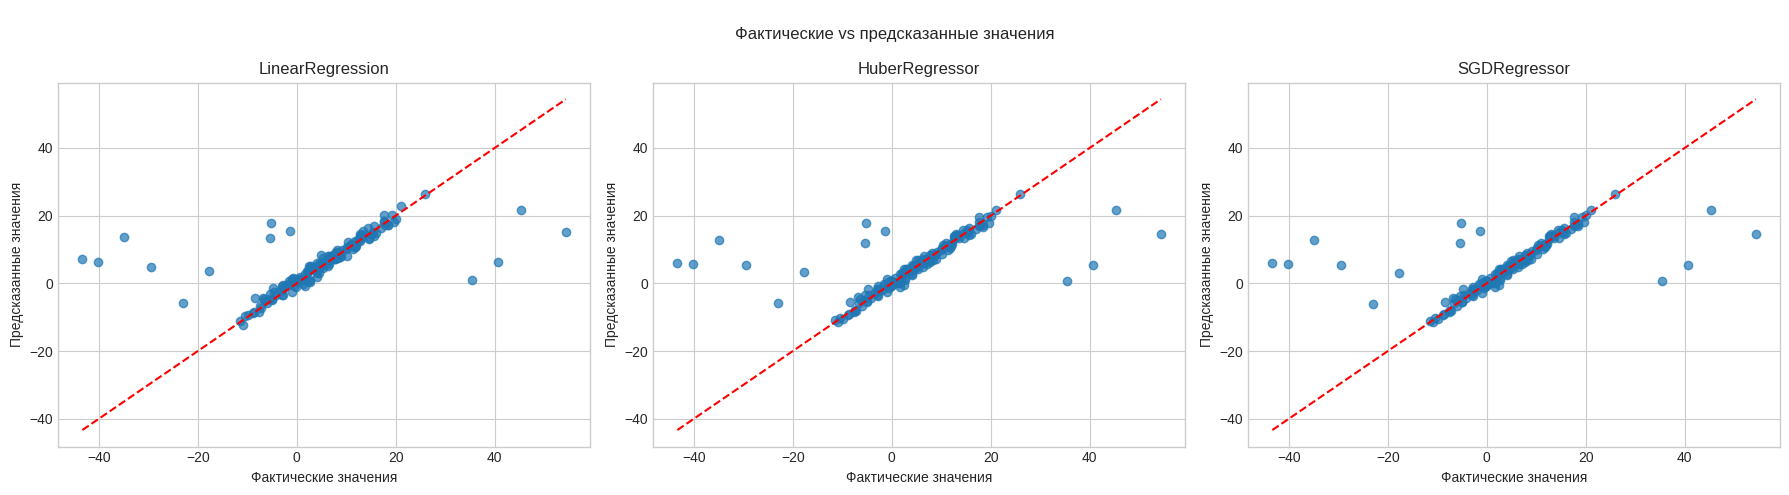

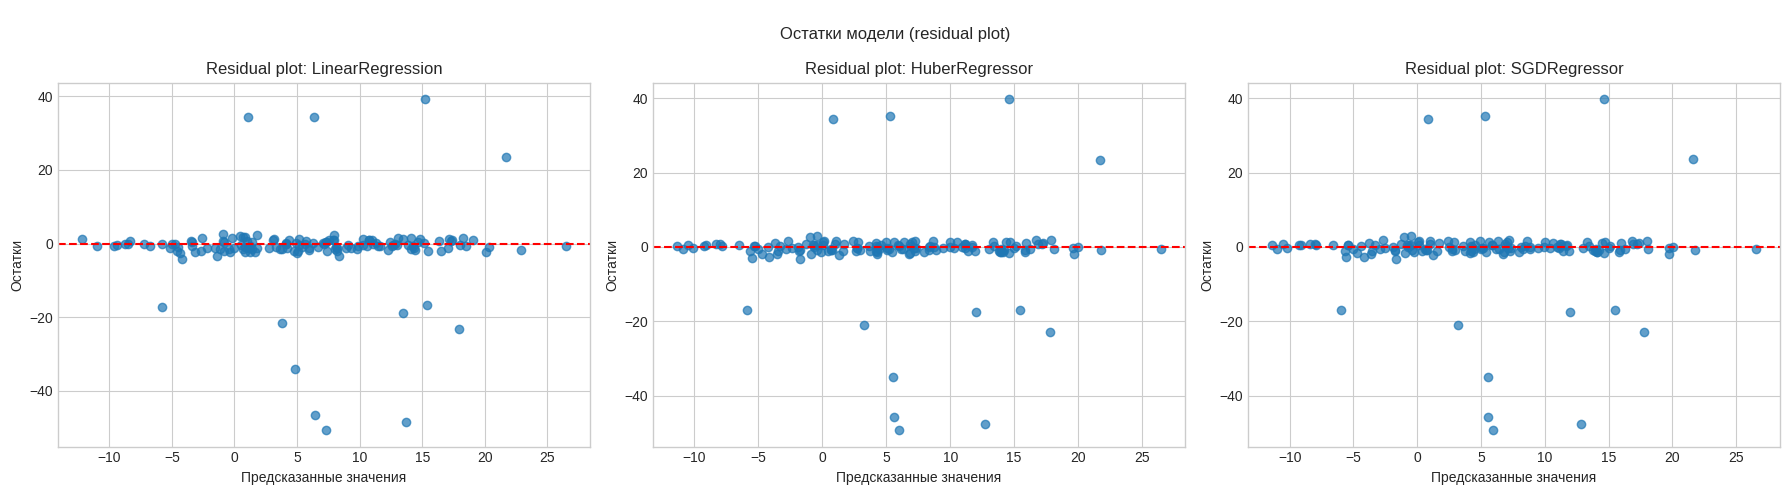

,Actual,LinearRegression,HuberRegressor,SGDRegressor
0,1.865456,1.360622,0.995837,1.019897
1,8.716530,9.049252,8.387751,8.416492
2,4.039047,3.107753,2.387420,2.394156
3,2.981101,5.041719,4.306750,4.350401
4,-29.355556,4.817272,5.514114,5.506892
5,7.306161,7.064269,6.957629,6.975291
6,5.374080,4.392267,4.205446,4.119870
7,9.231460,9.886829,9.401888,9.430696
8,-4.829521,-1.405151,-1.726738,-1.696569
9,-5.127911,17.931959,17.792836,17.791047


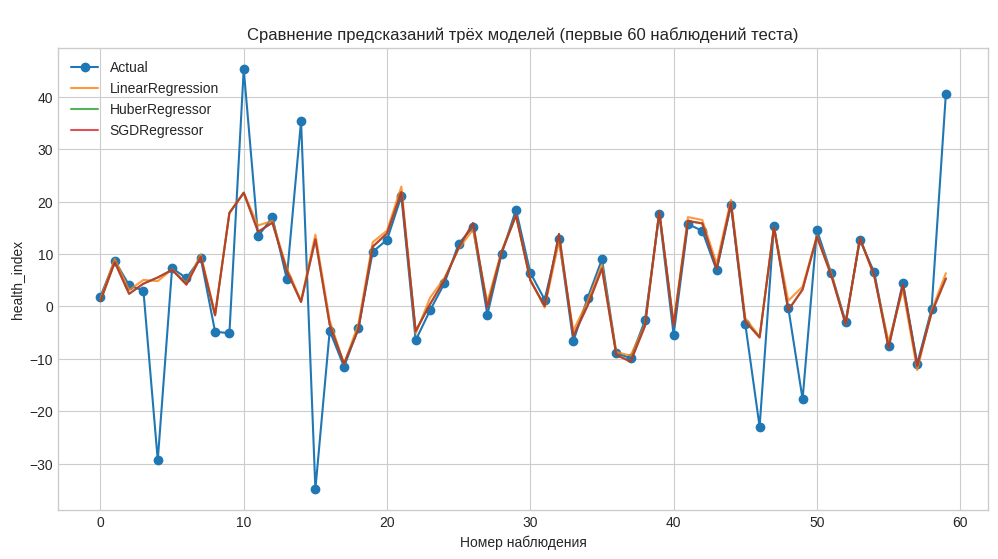

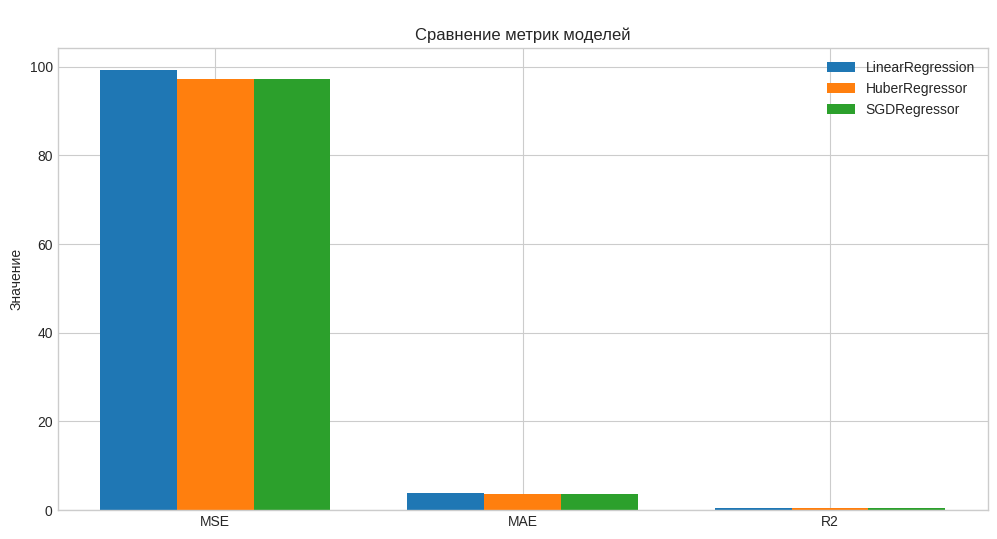

In [ ]:
# Выводим таблицу с уже рассчитанными метриками на тестовой выборке
# Здесь отображаются основные показатели качества моделей: MSE, RMSE, MAE и R2
print('Метрики на тестовой выборке')
display(metrics_df.round(4))

# Создаём область из 3 графиков в одной строке
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Проходим по всем моделям и их предсказаниям
# predictions.items() возвращает пары:(название модели, массив её предсказаний)
# zip(axes, predictions.items()) позволяет одновременно проходить по областям для графиков, по результатам каждой модели
for ax, (name, y_pred) in zip(axes, predictions.items()):

    # Строится scatter plot:
    # по оси X откладываются реальные значения target из y_test
    # по оси Y предсказанные моделью значения
    # Если модель работает хорошо, точки должны располагаться близко к диагональной линии y = x
    ax.scatter(y_test, y_pred, alpha=0.7)

    # Для построения диагональной линии идеального совпадения нужно найти общий диапазон значений по обеим осям
    # min_val - наименьшее значение среди реальных и предсказанных
    # max_val - наибольшее значение среди реальных и предсказанных
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())

    # Строится красная пунктирная линия y = x
    # Она показывает идеальный случай, когда предсказания полностью совпадают с фактическими значениями
    ax.plot([min_val, max_val], [min_val, max_val], 'r--')

    # Подписываем график названием модели
    ax.set_title(name)
    ax.set_xlabel('Фактические значения')
    ax.set_ylabel('Предсказанные значения')

plt.suptitle('\nФактические vs предсказанные значения')
plt.tight_layout()
plt.show()

# Остатки модели (residual plot)
# Если модель работает адекватно, остатки должны быть распределены примерно случайно вокруг нуля, без выраженной структуры
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Снова последовательно обрабатываются все модели
for ax, (name, y_pred) in zip(axes, predictions.items()):

    # Расчёт остатков для текущей модели
    residuals = y_test - y_pred

    # Строится scatter plot
    ax.scatter(y_pred, residuals, alpha=0.7)

    # Горизонтальная линия y = 0
    # Она показывает уровень, относительно которого оцениваются остатки
    # Чем более хаотично и симметрично точки расположены вокруг этой линии, тем лучше модель описывает данные
    ax.axhline(0, linestyle='--', color='red')
    ax.set_title(f'Residual plot: {name}')
    ax.set_xlabel('Предсказанные значения')
    ax.set_ylabel('Остатки')

plt.suptitle('\nОстатки модели (residual plot)')
plt.tight_layout()
plt.show()

# Сравнение предсказаний трёх моделей

# Создаётся отдельная таблица comparison_df, в которой:
# для каждого объекта тестовой выборки собираются фактические значения и предсказания всех трёх моделей
# y_test.values используется для получения массива значений target
# reset_index(drop=True) сбрасывает старый индекс
# чтобы таблица имела простой последовательный индекс от 0
# drop=True нужен, чтобы старый индекс не сохранился отдельным столбцом
comparison_df = pd.DataFrame({
    'Actual': y_test.values,
    'LinearRegression': predictions['LinearRegression'],
    'HuberRegressor': predictions['HuberRegressor'],
    'SGDRegressor': predictions['SGDRegressor']
}).reset_index(drop=True)

display(comparison_df.head(10))

# Строим линейный график только для первых 60 наблюдений тестовой выборки, чтобы график не был слишком перегруженным
plt.figure(figsize=(12, 6))

# Линия фактических значений
# marker='o' добавляет маркеры-точки
plt.plot(comparison_df['Actual'].values[:60], label='Actual', marker='o')

# Линии предсказаний трёх моделей
plt.plot(comparison_df['LinearRegression'].values[:60], label='LinearRegression', alpha=0.8)
plt.plot(comparison_df['HuberRegressor'].values[:60], label='HuberRegressor', alpha=0.8)
plt.plot(comparison_df['SGDRegressor'].values[:60], label='SGDRegressor', alpha=0.8)
plt.title('\nСравнение предсказаний трёх моделей (первые 60 наблюдений теста)')
plt.xlabel('Номер наблюдения')
plt.ylabel('health_index')
plt.legend()
plt.show()

#Сравнение метрик

# По условию здесь берутся: MSE, MAE, R2
metric_names = ['MSE', 'MAE', 'R2']

# np.arange(len(metric_names)) создаёт массив позиций по оси X для трёх метрик это будет [0, 1, 2]
x = np.arange(len(metric_names))
width = 0.25

# Строим столбчатую диаграмму
plt.figure(figsize=(12, 6))

# enumerate(results_df['Method']) проходит по названиям моделей и одновременно даёт их порядковый номер idx
# idx нужен для сдвига столбцов по оси X, чтобы столбцы разных моделей не накладывались друг на друга
for idx, model_name in enumerate(results_df['Method']):

    # Из таблицы results_df выбираются значения нужных метрик только для текущей модели
    # results_df['Method'] == model_name логическое условие отбора строк
    # metric_names список нужных столбцов .values.flatten() превращает результат в одномерный массив, чтобы его было удобно передать в plt.bar()
    values = results_df.loc[results_df['Method'] == model_name, metric_names].values.flatten()

    # Строятся столбцы для текущей модели
    # x + idx * width сдвигает столбцы вправо
    plt.bar(x + idx * width, values, width=width, label=model_name)

# Подписываем ось X названиями метрик
plt.xticks(x + width, metric_names)
plt.title('\nСравнение метрик моделей')
plt.ylabel('Значение')
plt.legend()
plt.show()

На этапе оценки качества были рассчитаны метрики MSE, RMSE, MAE и R² для всех трёх моделей на тестовой выборке. Также были построены графики фактических и предсказанных значений, residual plot и визуальное сравнение предсказаний моделей. По полученным результатам было показано, насколько точно каждая модель описывает данные и как выбросы влияют на качество прогноза. В итоге этот этап позволил наглядно сравнить поведение моделей

### Этап 5: Анализ устойчивости
1. Исследуйте влияние выбросов на каждую модель
2. Проанализируйте, как параметр `epsilon` влияет на робастность HuberRegressor
3. Сделайте выводы о применимости каждой функции потерь

Сравнение качества моделей на данных с выбросами и без выбросов:


,Method,MSE_with_outliers,RMSE_with_outliers,MAE_with_outliers,R2_with_outliers,MSE_without_outliers,RMSE_without_outliers,MAE_without_outliers,R2_without_outliers
0,LinearRegression,99.2390,9.9619,3.7665,0.3738,8.9133,2.9855,1.2377,0.8797
1,HuberRegressor,97.2994,9.8640,3.5367,0.3860,9.2410,3.0399,1.1965,0.8753
2,SGDRegressor,97.2647,9.8623,3.5346,0.3863,9.2400,3.0397,1.1955,0.8753


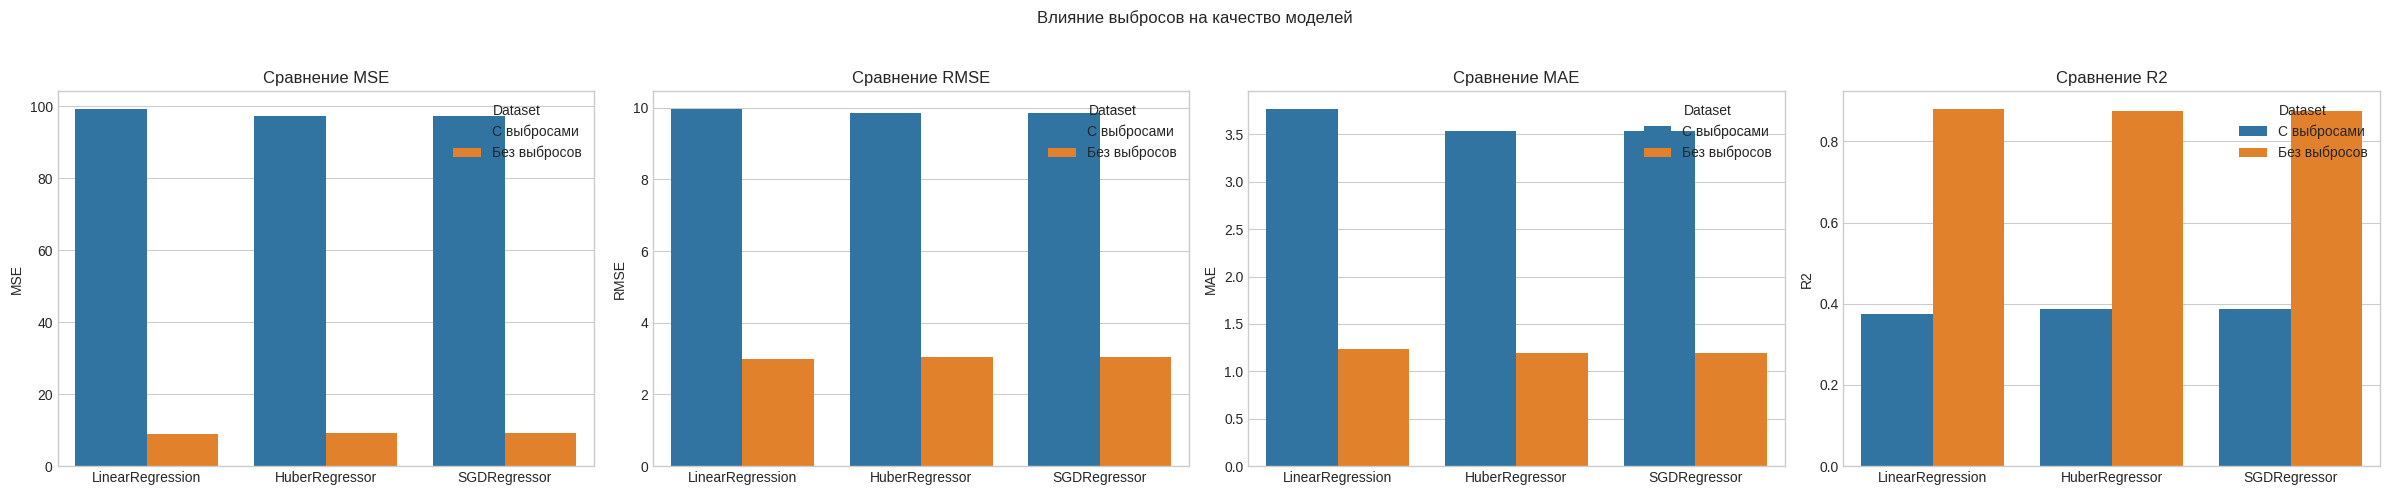

Влияние параметра epsilon в HuberRegressor:


,epsilon,MSE,RMSE,MAE,R2
0,1.00,97.2704,9.8626,3.5364,0.3862
1,1.10,97.3191,9.8650,3.5364,0.3859
2,1.20,97.2636,9.8622,3.5350,0.3863
3,1.35,97.2994,9.8640,3.5367,0.3860
4,1.50,97.2895,9.8635,3.5370,0.3861
5,1.80,97.3142,9.8648,3.5382,0.3859
6,2.00,97.3341,9.8658,3.5392,0.3858
7,2.50,97.3346,9.8658,3.5402,0.3858


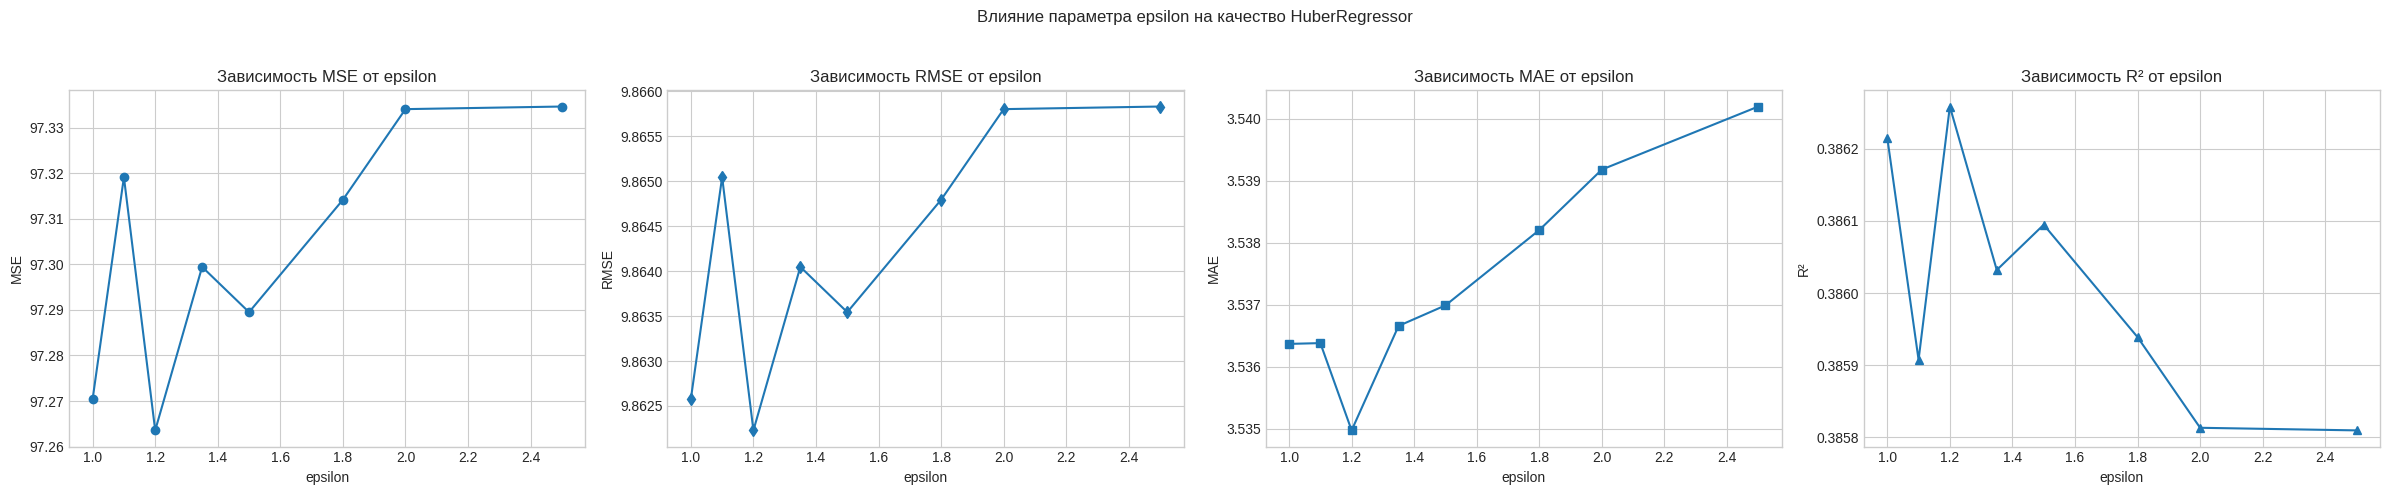

In [ ]:
# detected_outliers уже был получен ранее методом IQR
# В detected_outliers находятся строки исходного DataFrame, которые были определены как выбросы по целевой переменной
# df.drop(index=detected_outliers.index) удаляет из исходного DataFrame все строки, индексы которых совпадают с индексами выбросов
df_no_outliers = df.drop(index=detected_outliers.index).copy()

# Выделяем признаки и целевую переменную для очищенного набора
X_clean = df_no_outliers[feature_names]
y_clean = df_no_outliers[target_name]

# Очищенные данные снова делятся на обучающую и тестовую выборки, чтобы сравнение было проведено отдельно на наборе без выбросов
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clean, y_clean, test_size=0.30, random_state=25
)

# Масштабирование признаков для очищенных данных
scaler_clean = StandardScaler()
X_train_c_scaled = scaler_clean.fit_transform(X_train_c)
X_test_c_scaled = scaler_clean.transform(X_test_c)

# Создаём модели для обучения на данных без выбросов
clean_models = {
    'LinearRegression': LinearRegression(),
    'HuberRegressor': HuberRegressor(epsilon=epsilon_huber, max_iter=1000),
    'SGDRegressor': SGDRegressor(
        loss=sgd_loss,
        max_iter=sgd_iters,
        eta0=learning_rate,
        learning_rate='constant',
        penalty=None,
        tol=None,
        random_state=25
    )
}

# Список clean_results будет хранить результаты каждой модели после обучения на данных без выбросов
clean_results = []

# Цикл проходит по всем моделям из словаря clean_models
for model_name, model in clean_models.items():

    # Для каждой модели вызывается ранее созданная функция evaluate_model()
    result, _ = evaluate_model(
        model,
        X_train_c_scaled,
        X_test_c_scaled,
        y_train_c,
        y_test_c,
        model_name
    )

    # Словарь с результатами добавляется в список clean_results
    clean_results.append(result)

# Создание DataFrame для более удобного анализа данных
clean_results_df = pd.DataFrame(clean_results)

# Сравниваем качество моделей на данных с выбросами и без выбросов

# results_df уже был получен ранее на исходных данных с выбросами
# clean_results_df получен только что на очищенных данных
# Затем выполняется merge() по столбцу Method, чтобы значения одной и той же модели стояли в одной строке
# suffixes=('_with_outliers', '_without_outliers') добавляет понятные суффиксы к названиям метрик
robust_compare = results_df[['Method', 'MSE', 'RMSE', 'MAE', 'R2']].merge(
    clean_results_df[['Method', 'MSE', 'RMSE', 'MAE', 'R2']],
    on='Method',
    suffixes=('_with_outliers', '_without_outliers')
)

print('Сравнение качества моделей на данных с выбросами и без выбросов:')
display(robust_compare.round(4))

# Визуализация влияния выбросов на метрики моделей

# Список метрик, которые будут сравниваться на графиках
# Для каждой из них будет отдельный подграфик
metrics_to_plot = ['MSE', 'RMSE', 'MAE', 'R2']
fig, axes = plt.subplots(1, 4, figsize=(24, 5))

# Одновременно перебираются области для графиков (axes), названия метрик (metrics_to_plot)
for ax, metric in zip(axes, metrics_to_plot):

    # Из robust_compare выбираются три столбца название модели, значение метрики с выбросами и без
    # .melt() преобразует таблицу из "широкого" формата в "длинный".
    # Это нужно для удобного построения графика seaborn.barplot().
    plot_df = robust_compare[
        ['Method', f'{metric}_with_outliers', f'{metric}_without_outliers']
    ].melt(
        id_vars='Method',
        var_name='Dataset',
        value_name=metric
    )

    # Замена технических названий на более читаемые подписи.
    plot_df['Dataset'] = plot_df['Dataset'].replace({
        f'{metric}_with_outliers': 'С выбросами',
        f'{metric}_without_outliers': 'Без выбросов'
    })

    # Строится столбчатая диаграмма
    sns.barplot(data=plot_df, x='Method', y=metric, hue='Dataset', ax=ax)
    ax.set_title(f'Сравнение {metric}')
    ax.set_xlabel('')
    ax.set_ylabel(metric)

plt.suptitle('Влияние выбросов на качество моделей')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Анализ влияния параметра epsilon в HuberRegressor

# Для анализа задаётся несколько значений epsilon
epsilon_values = [1.0, 1.1, 1.2, 1.35, 1.5, 1.8, 2.0, 2.5]

# Список для хранения результатов по каждому значению epsilon
epsilon_results = []

# Для каждого значения epsilon создаётся и обучается отдельная модель
for eps in epsilon_values:

    # Создание HuberRegressor с текущим значением epsilon
    huber_model = HuberRegressor(epsilon=eps, max_iter=1000)

    # Обучение модели на исходных данных с выбросами, чтобы проверить как epsilon влияет на устойчивость именно в присутствии выбросов
    huber_model.fit(X_train_scaled, y_train)

    # Предсказания на тестовой выборке
    y_pred_eps = huber_model.predict(X_test_scaled)

    # Расчёт метрик качества для текущего epsilon
    mse = mean_squared_error(y_test, y_pred_eps)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred_eps)
    r2 = r2_score(y_test, y_pred_eps)

    # Сохранение результатов в виде словаря
    epsilon_results.append({
        'epsilon': eps,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    })

# Создание DataFrame для более удобного анализа данных
epsilon_df = pd.DataFrame(epsilon_results)

print('Влияние параметра epsilon в HuberRegressor:')
display(epsilon_df.round(4))

# Визуализация влияния epsilon на метрики HuberRegressor
fig, axes = plt.subplots(1, 4, figsize=(24, 5))

# График зависимости MSE от epsilon
axes[0].plot(epsilon_df['epsilon'], epsilon_df['MSE'], marker='o')
axes[0].set_title('Зависимость MSE от epsilon')
axes[0].set_xlabel('epsilon')
axes[0].set_ylabel('MSE')

# График зависимости RMSE от epsilon
axes[1].plot(epsilon_df['epsilon'], epsilon_df['RMSE'], marker='d')
axes[1].set_title('Зависимость RMSE от epsilon')
axes[1].set_xlabel('epsilon')
axes[1].set_ylabel('RMSE')

# График зависимости MAE от epsilon
axes[2].plot(epsilon_df['epsilon'], epsilon_df['MAE'], marker='s')
axes[2].set_title('Зависимость MAE от epsilon')
axes[2].set_xlabel('epsilon')
axes[2].set_ylabel('MAE')

# График зависимости R² от epsilon
axes[3].plot(epsilon_df['epsilon'], epsilon_df['R2'], marker='^')
axes[3].set_title('Зависимость R² от epsilon')
axes[3].set_xlabel('epsilon')
axes[3].set_ylabel('R²')

plt.suptitle('Влияние параметра epsilon на качество HuberRegressor')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

Было показано, что параметр epsilon напрямую влияет на робастность HuberRegressor. При меньших значениях epsilon модель слабее реагирует на выбросы и ведёт себя устойчивее, а при увеличении epsilon её поведение становится ближе к обычной линейной регрессии, из-за чего чувствительность к аномальным значениям возрастает. В итоге подбор epsilon позволяет найти баланс между устойчивостью к выбросам и точностью аппроксимации.

По результатам сравнения моделей было установлено, что функция потерь MSE хорошо работает на данных без сильных выбросов, но заметно чувствительна к аномальным наблюдениям. Huber оказалась более универсальной, поскольку лучше сохраняет устойчивость при наличии выбросов. Функция потерь huber в SGDRegressor тоже показывает робастные свойства, но качество модели сильнее зависит от настройки параметров обучения. Вследствие этого Huber loss можно считать наиболее подходящим вариантом для задач, где в данных возможны выбросы.

##  Ответы на контрольные вопросы

1. Почему MSE более чувствительна к выбросам, чем MAE? Приведите математическое обоснование через производные.

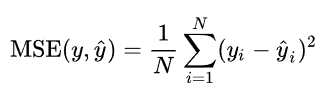

Из-за квадрата разности в формуле выше, MSE чувствительна к выбросам и более сложна для восприятия по сравнению с MAE.

2. Как параметр `epsilon` в Huber loss влияет на поведение модели? При каких значениях она ведёт себя как MSE, а при каких — как MAE?

Huber loss сочетает MSE и MAE:
- при малых ошибках работает как квадрат ошибки;
- при больших ошибках — как модуль ошибки.

Если epsilon маленький, модель быстрее начинает считать ошибки «большими», значит становится более робастной.  
Если epsilon большой, функция дольше ведёт себя как MSE, то есть сильнее реагирует на выбросы.  
Следовательно:
- маленький epsilon поведение ближе к MAE;
- большой epsilon поведение ближе к MSE.

3. Почему масштабирование признаков важно для SGDRegressor? Что произойдёт, если признаки имеют разный масштаб?

SGDRegressor оптимизирует функцию потерь методом градиентного спуска, поэтому масштаб признаков напрямую влияет на величину градиентов. При существенной разнице диапазонов признаки начинают вносить неодинаковый вклад в обновление параметров: для одних коэффициентов шаг обновления оказывается большим, тогда как для других — очень малым. Это приводит к несбалансированной динамике обучения и ухудшает сходимость.

4. В каких практических задачах предпочтительнее использовать Huber loss вместо MSE? Приведите 2-3 примера.

Huber loss целесообразно использовать вместо MSE в задачах регрессии, где в данных присутствуют выбросы или редкие аномальные наблюдения. В отличие от MSE, Huber снижает влияние крупных ошибок на обучение, сохраняя при этом квадратичное поведение для небольших отклонений.

Примеры:

Оценка стоимости недвижимости или автомобилей. В данных встречаются редкие очень дорогие объекты и ошибки в объявлениях, которые могут непропорционально влиять на модель при использовании MSE.

Прогноз продаж/спроса. Пиковые значения из-за акций, праздников или разовых крупных заказов являются нетипичными и при использовании MSE могут чрезмерно влиять на обучение, из-за чего качество модели на большинстве периодов без таких всплесков снижается.

5. Как интерпретировать отрицательное значение R²? О чём это говорит о модели?

Отрицательный R² означает, что модель предсказывает хуже, чем простая константа, равная среднему значению целевой переменной.
То есть модель практически не уловила зависимость в данных или была обучена неудачно.

6. Почему при увеличении learning rate модель может "разойтись"? Проиллюстрируйте на примере формулы обновления весов.

При градиентном спуске веса обновляются по правилу:

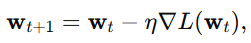

где η — learning rate. Если η слишком велик, шаг обновления становится чрезмерным: обновления перестают устойчиво приближать параметры к минимуму, возникают колебания вокруг него, и значение функции потерь L может начать увеличиваться, что приводит к расходимости.

7. Как наличие мультиколлинеарности влияет на коэффициенты линейной регрессии? Как это можно обнаружить?

Если признаки сильно коррелируют друг с другом, модели трудно понять, какой из них действительно отвечает за изменение цели.  
Из-за этого:
- коэффициенты становятся нестабильными;
- могут менять знак;
- интерпретация ухудшается.

Обнаружить проблему можно по:
- матрице корреляций;
- VIF (variance inflation factor);
- сильным изменениям коэффициентов при добавлении/удалении признаков.

8. В чём разница между стохастическим, мини-батч и пакетным градиентным спуском? Когда какой использовать?

- Пакетный (batch): использует весь датасет для одного шага. Стабилен, но медленный на больших данных.
- Стохастический (SGD): обновляет веса после каждого объекта. Быстрый, но шумный.
- Мини-батч: использует небольшие группы объектов. Это компромисс между скоростью и стабильностью.

Обычно:
- batch — для небольших данных;
- SGD — для очень больших или потоковых данных;
- mini-batch — самый популярный вариант в практических задачах.